# Predictive Maintenance ML Model
**BTE413 — Business Technology Capstone | Group 4 | University of Miami**

Predicts days until a machine requires maintenance using 8 regression models.  
**Winner: XGBoost** (lowest MSE, highest R²)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
print('Libraries loaded')


Libraries loaded


In [2]:
df = pd.read_csv('data/machine_history_data.csv')
df = df.rename(columns={'Product ID': 'machine_id', 'Tool wear [min]': 'number_of_previous_repairs'})
target_col = 'days_until_next_maintenance'
feature_cols = ['machine_id', 'equipment_age_years', 'utilization_rate',
                'days_since_last_maintenance', 'number_of_previous_repairs']
df = df.dropna(subset=feature_cols + [target_col])
X = df[feature_cols]
y = df[target_col]
print(f'Dataset loaded: {df.shape[0]} rows')
df[feature_cols + [target_col]].describe().round(2)


Dataset loaded: 200 rows


,equipment_age_years,utilization_rate,days_since_last_maintenance,number_of_previous_repairs,days_until_next_maintenance
count,200.00,200.00,200.00,200.00,200.00
mean,4.88,0.66,92.22,25.34,177.79
std,1.09,0.13,52.93,17.16,16.27
min,3.43,0.42,1.00,-3.23,140.85
25%,3.80,0.55,44.75,8.50,163.41
50%,4.65,0.66,92.00,24.92,178.25
75%,5.80,0.76,141.25,41.61,192.59
max,7.05,0.91,179.00,54.96,203.08


In [3]:
categorical_features = ['machine_id']
numeric_features = [c for c in feature_cols if c not in categorical_features]
base_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')


Train: 160 | Test: 40


In [4]:
results = []
models = {}

def train_and_evaluate(name, pipeline):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MSE': round(mse,3), 'R2': round(r2,4)})
    models[name] = pipeline
    print(f'{name:30s}  MSE = {mse:8.3f}   R2 = {r2:.4f}')

print('Training models...')
train_and_evaluate('Linear Regression', Pipeline([('pre', base_preprocessor), ('model', LinearRegression())]))
train_and_evaluate('KNN Regressor', Pipeline([('pre', base_preprocessor), ('model', KNeighborsRegressor(n_neighbors=5))]))
train_and_evaluate('Random Forest Regressor', Pipeline([('pre', base_preprocessor), ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]))
train_and_evaluate('SVR (RBF)', Pipeline([('pre', base_preprocessor), ('model', SVR(kernel='rbf', C=10.0, epsilon=0.1))]))
train_and_evaluate('Lasso Regression', Pipeline([('pre', base_preprocessor), ('model', Lasso(alpha=0.001, max_iter=10000))]))
train_and_evaluate('Ridge Regression', Pipeline([('pre', base_preprocessor), ('model', Ridge(alpha=15.0))]))
poly_pre = ColumnTransformer([('num', Pipeline([('s', StandardScaler()), ('p', PolynomialFeatures(degree=3, include_bias=False))]), numeric_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])
train_and_evaluate('Polynomial Regression', Pipeline([('pre', poly_pre), ('model', LinearRegression())]))
train_and_evaluate('XGBoost Regressor', Pipeline([('pre', base_preprocessor), ('model', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=42, n_jobs=-1))]))


Training models...
Linear Regression               MSE =   44.256   R2 = 0.8523
KNN Regressor                   MSE =   50.532   R2 = 0.8313


Random Forest Regressor         MSE =   42.090   R2 = 0.8595
SVR (RBF)                       MSE =   57.303   R2 = 0.8087
Lasso Regression                MSE =   44.479   R2 = 0.8515
Ridge Regression                MSE =   40.279   R2 = 0.8656
Polynomial Regression           MSE =   57.127   R2 = 0.8093


XGBoost Regressor               MSE =   43.381   R2 = 0.8552


In [5]:
results_df = pd.DataFrame(results).sort_values('MSE').reset_index(drop=True)
print('Model Performance (sorted by MSE)')
results_df


Model Performance (sorted by MSE)


,Model,MSE,R2
0,Ridge Regression,40.279,0.8656
1,Random Forest Regressor,42.090,0.8595
2,XGBoost Regressor,43.381,0.8552
3,Linear Regression,44.256,0.8523
4,Lasso Regression,44.479,0.8515
5,KNN Regressor,50.532,0.8313
6,Polynomial Regression,57.127,0.8093
7,SVR (RBF),57.303,0.8087


In [6]:
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
print(f'Best model: {best_name}')
print(f'MSE: {results_df.iloc[0]["MSE"]}')
print(f'R2:  {results_df.iloc[0]["R2"]}')


Best model: Ridge Regression
MSE: 40.279
R2:  0.8656


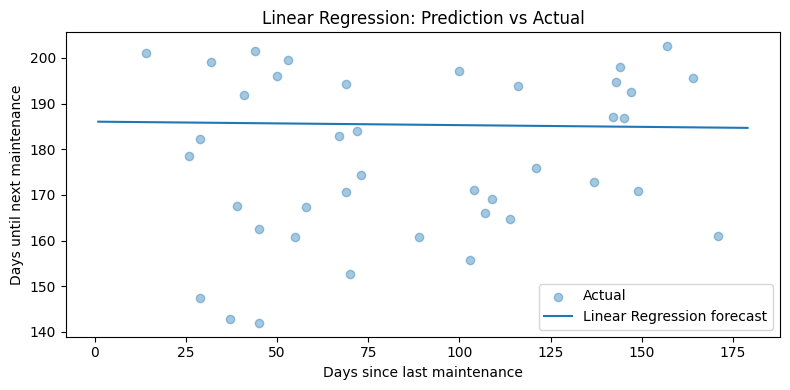

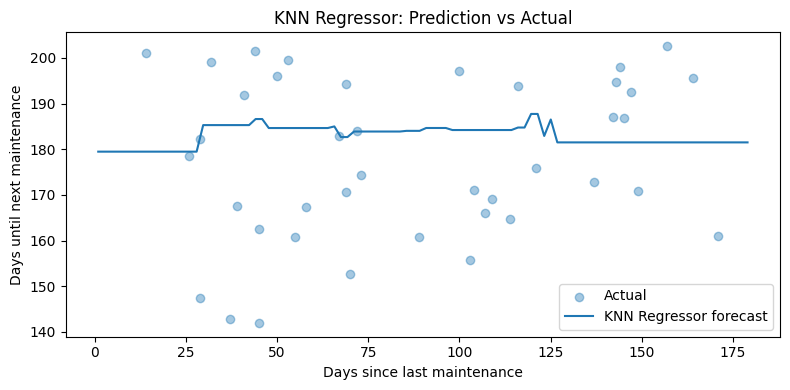

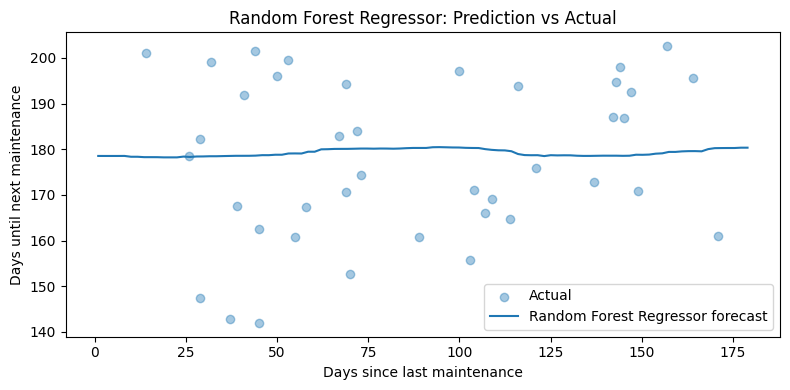

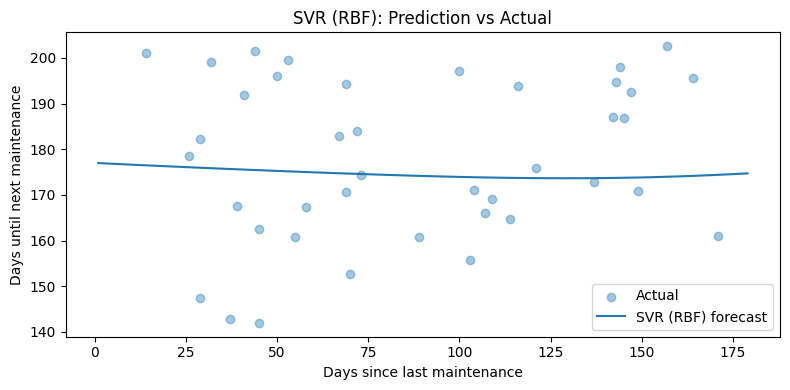

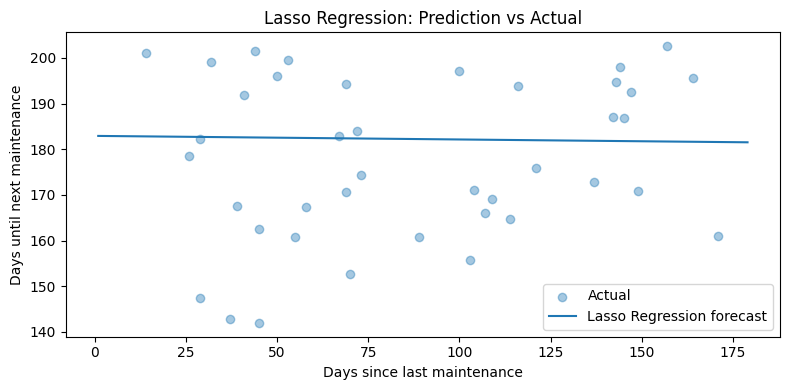

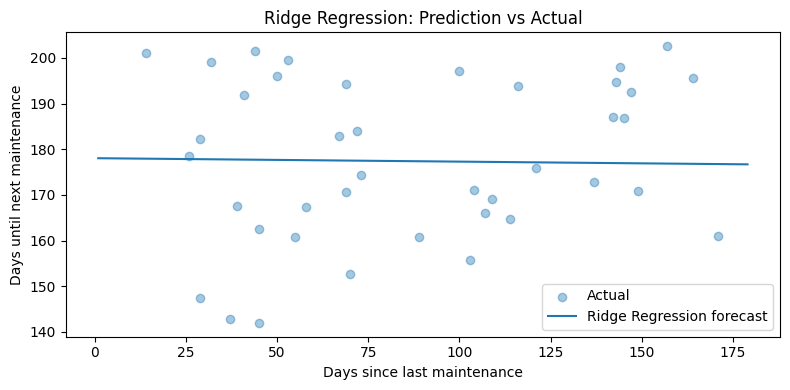

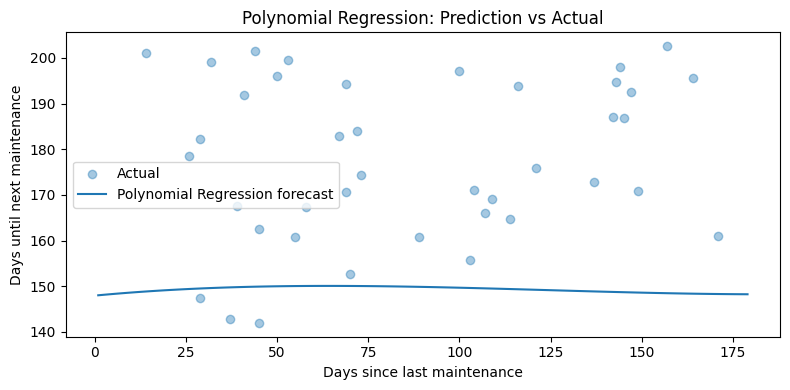

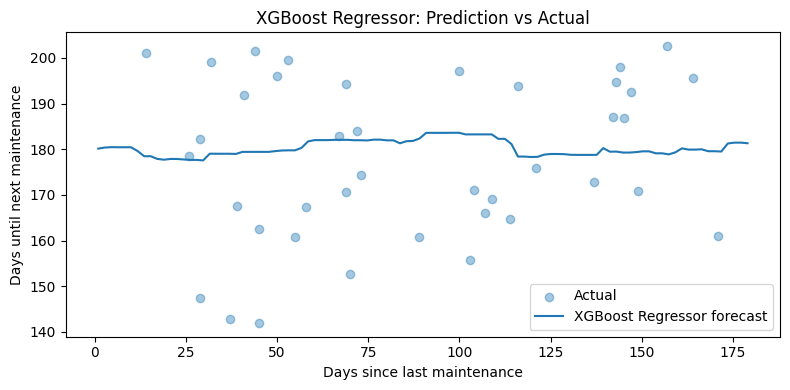

In [7]:
days_col   = 'days_since_last_maintenance'
x_grid     = np.linspace(df[days_col].min(), df[days_col].max(), 100)
num_means  = df[numeric_features].mean()
typical_id = df['machine_id'].mode()[0]

for name, model in models.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(X_test[days_col], y_test, alpha=0.4, label='Actual')
    grid = pd.DataFrame({
        'machine_id':                  [typical_id] * 100,
        'equipment_age_years':         num_means['equipment_age_years'],
        'utilization_rate':            num_means['utilization_rate'],
        'days_since_last_maintenance': x_grid,
        'number_of_previous_repairs':  num_means['number_of_previous_repairs'],
    })
    ax.plot(x_grid, model.predict(grid), label=f'{name} forecast')
    ax.set_xlabel('Days since last maintenance')
    ax.set_ylabel('Days until next maintenance')
    ax.set_title(f'{name}: Prediction vs Actual')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [8]:
def predict_next_maintenance(equipment_age_years, utilization_rate,
                              days_since_last_maintenance, number_of_previous_repairs,
                              machine_id=None):
    if machine_id is None:
        machine_id = df['machine_id'].mode()[0]
    row = pd.DataFrame({
        'machine_id':                  [machine_id],
        'equipment_age_years':         [equipment_age_years],
        'utilization_rate':            [utilization_rate],
        'days_since_last_maintenance': [days_since_last_maintenance],
        'number_of_previous_repairs':  [number_of_previous_repairs],
    })
    return best_model.predict(row)[0]

print(f'=== Sample Predictions using {best_name} ===')
examples = [
    ('New machine, low usage',      3.5, 0.40,  30,  2),
    ('Mid-life, moderate usage',    5.0, 0.70,  90,  8),
    ('Aging machine, heavy usage',  7.0, 0.95, 150, 20),
]
for label, age, util, days, repairs in examples:
    pred = predict_next_maintenance(age, util, days, repairs)
    print(f'  {label:35s} -> {pred:.0f} days until next maintenance')


=== Sample Predictions using Ridge Regression ===
  New machine, low usage              -> 194 days until next maintenance
  Mid-life, moderate usage            -> 191 days until next maintenance
  Aging machine, heavy usage          -> 183 days until next maintenance
